In [ ]:
import pandas as pd


In [ ]:
import os

os.listdir()

['.config', 'questionsv4.csv', 'sample_data']

In [ ]:
import pandas as pd

df = pd.read_csv("questionsv4.csv")

In [ ]:
df.head()

,questions,answers
0,asking about the control measure for aphid inf...,suggested him to spray rogor@2ml/lit.at evenin...
1,asking about the control measure of flower dro...,suggested him to apply fertilizer in recommend...
2,asking about how to avail kisan credit card lo...,suggested to consult with officer-marketing an...
3,asking about source of early ahu rice variety,suggested to take early ahu rice variety from ...
4,asking that he has not got proper friut from h...,suggested him to aplly recommended fertilizer ...


In [ ]:
print("="*50)
print("DATASET INFORMATION")
print("="*50)

df.info()

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178939 entries, 0 to 178938
Data columns (total 2 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   questions  178939 non-null  object
 1   answers    178816 non-null  object
dtypes: object(2)
memory usage: 2.7+ MB


In [ ]:
print("Dataset Shape:", df.shape)
print("\nNumber of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

Dataset Shape: (178939, 2)

Number of Rows : 178939
Number of Columns : 2


In [ ]:
print(df.columns)

Index(['questions', 'answers'], dtype='object')


In [ ]:
print(df.isnull().sum())

questions      0
answers      123
dtype: int64


In [ ]:
duplicates = df.duplicated().sum()

print("Duplicate Rows :", duplicates)

Duplicate Rows : 37839


In [ ]:
df.sample(10, random_state=42)

,questions,answers
158880,asking about management problem in fish pond,explained in details
27084,asking about feeding practices of fish,adviced to feed with 'rice brane and moc' @ 18...
113196,asking about treatment of diarrhoea in cow.,suggested to administer nt-zole bolus @ 1 bolu...
121715,asking about the control of brown leaf hopper,suggested him to spray tricel 20 ec @ 2ml/lite...
21278,asking about the control measure of powdery mi...,suggested to apply sulfex @ 2 gram / litre of ...
74867,asking about the benefit and minimum expenditu...,benefit of low cost green house is that off se...
83728,asking about the control measure of root rot d...,advised to apply captan @ 3 gram / litre of wa...
78061,asking about the control measure for fungal wi...,"recommended to spray contaf(hexaconazole),1.5 ..."
125600,asked about water quality of a pond\n\n,apply lime - 8 kg/bigha/monthly
4189,asking about air layering process of litchi,explained him in details


In [ ]:
df.describe(include='all')

,questions,answers
count,178939,178816
unique,90930,99353
top,query regarding pmkisan.,explain in details
freq,1065,3130


In [ ]:
df["query_length"] = df["questions"].apply(len)

df["query_length"].describe()

,query_length
count,178939.000000
mean,43.649618
std,39.868269
min,1.000000
25%,32.000000
50%,42.000000
75%,51.000000
max,10239.000000


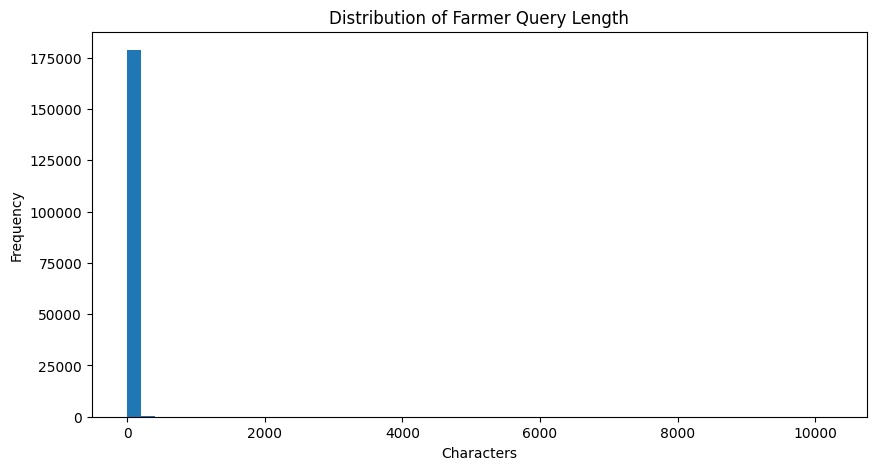

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(df["query_length"], bins=50)

plt.title("Distribution of Farmer Query Length")

plt.xlabel("Characters")

plt.ylabel("Frequency")

plt.show()

In [ ]:
print(df.loc[df["query_length"].idxmax(), "questions"])

asking about control measure of blight of cucumber 
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    

In [ ]:
print(df.loc[df["query_length"].idxmin(), "questions"])

w


In [ ]:
df.to_csv("clean_dataset.csv", index=False)

print("Dataset Saved Successfully")

Dataset Saved Successfully


In [ ]:
print("Minimum Length :", df["query_length"].min())
print("Maximum Length :", df["query_length"].max())
print("Average Length :", df["query_length"].mean())

print("\nLongest Query:\n")
print(df.loc[df["query_length"].idxmax(), "questions"])

Minimum Length : 1
Maximum Length : 10239
Average Length : 43.64961802625476

Longest Query:

asking about control measure of blight of cucumber 
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      

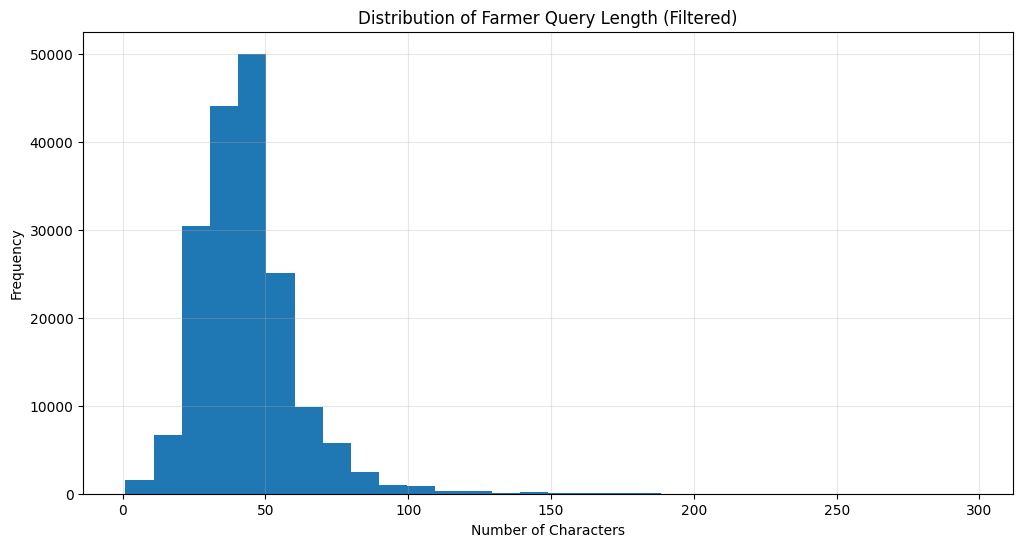

In [ ]:
import matplotlib.pyplot as plt

# Keep only queries shorter than 300 characters
filtered = df[df["query_length"] < 300]

plt.figure(figsize=(12,6))
plt.hist(filtered["query_length"], bins=30)

plt.title("Distribution of Farmer Query Length (Filtered)")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.show()

In [ ]:
df["word_count"] = df["questions"].str.split().str.len()

df["word_count"].describe()

,word_count
count,178939.000000
mean,7.069744
std,3.434427
min,0.000000
25%,5.000000
50%,7.000000
75%,8.000000
max,189.000000


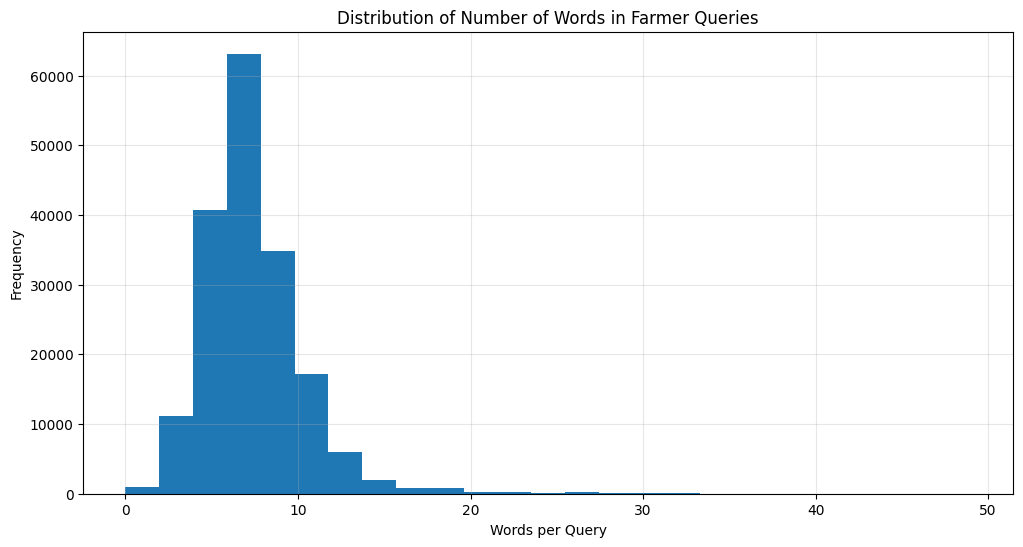

In [ ]:
plt.figure(figsize=(12,6))

plt.hist(df[df["word_count"] < 50]["word_count"], bins=25)

plt.title("Distribution of Number of Words in Farmer Queries")
plt.xlabel("Words per Query")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.show()

In [ ]:
# High Priority Keywords
high_keywords = [
    "disease", "pest", "insect", "attack", "aphid",
    "borer", "shoot borer", "stem borer",
    "fungus", "fungal", "virus", "viral",
    "blight", "leaf blight",
    "rot", "stem rot", "root rot",
    "wilt", "wilting",
    "yellow", "yellowing",
    "spot", "leaf spot",
    "hopper",
    "thrips",
    "mites",
    "mealybug",
    "whitefly",
    "armyworm",
    "locust",
    "dried", "drying", "dead",
    "infection",
    "damping off",
    "mildew",
    "blast"
]
# Medium Priority Keywords
medium_keywords = [
    "fertilizer",
    "fertiliser",
    "spray",
    "irrigation",
    "water",
    "soil",
    "seed",
    "sowing",
    "harvesting",
    "harvest",
    "transplant",
    "nursery",
    "cultivation",
    "crop management",
    "weed",
    "manure",
    "nutrient",
    "dosage",
    "dose",
    "variety",
    "yield"
]

# Low Priority Keywords
low_keywords = [
    "loan",
    "credit",
    "kisan credit card",
    "pm kisan",
    "samman nidhi",
    "yojana",
    "scheme",
    "government",
    "subsidy",
    "insurance",
    "market",
    "price",
    "mandi",
    "registration",
    "training"
]

In [ ]:
def assign_priority(question):

    question = str(question).lower()

    for word in high_keywords:
        if word in question:
            return "High"

    for word in medium_keywords:
        if word in question:
            return "Medium"

    for word in low_keywords:
        if word in question:
            return "Low"

    return "Medium"

In [ ]:
df["Priority"] = df["questions"].apply(assign_priority)

df.head()

,questions,answers,query_length,word_count,Priority
0,asking about the control measure for aphid inf...,suggested him to spray rogor@2ml/lit.at evenin...,71,11,High
1,asking about the control measure of flower dro...,suggested him to apply fertilizer in recommend...,76,13,Medium
2,asking about how to avail kisan credit card lo...,suggested to consult with officer-marketing an...,63,12,Low
3,asking about source of early ahu rice variety,suggested to take early ahu rice variety from ...,45,8,Medium
4,asking that he has not got proper friut from h...,suggested him to aplly recommended fertilizer ...,62,12,Medium


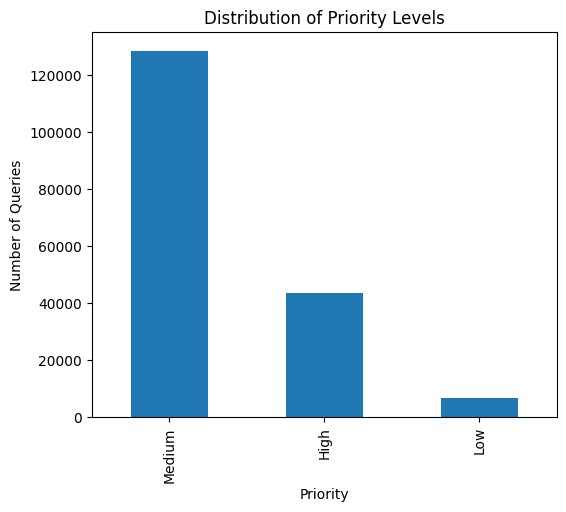

In [ ]:
import matplotlib.pyplot as plt

priority_counts = df["Priority"].value_counts()

plt.figure(figsize=(6,5))
priority_counts.plot(kind="bar")

plt.title("Distribution of Priority Levels")
plt.xlabel("Priority")
plt.ylabel("Number of Queries")

plt.show()

In [ ]:
df.sample(20)[["questions", "Priority"]]

,questions,Priority
2008,seeking loan for fish pond construction,Low
35504,asking about the control of flower drop of pum...,Medium
49087,asking for the fertilizers dosages in terms of...,Medium
25147,asking about cultural practices of squash,Medium
131730,asking about the disease problem in bhindi,High
134004,asking direct seeded ahu rice variety,Medium
153952,asking about control of blight in potato,High
56609,asking about the control measure for mole cric...,Medium
3167,asking about pm kisan samman nidhi yojana,Medium
5988,asking about the control measure of shoot borer,Medium


In [ ]:
df["Priority"].value_counts()

,count
Priority,
Medium,128688
High,43617
Low,6634


In [ ]:
# -------------------------------
# Intent Classification
# -------------------------------

intent_keywords = {

    "Disease": [
        "disease","blight","rot","wilt","virus","fungus","fungal",
        "yellow","spot","infection","blast","mildew","bacterial"
    ],

    "Pest": [
        "pest","aphid","borer","shoot borer","stem borer","thrips",
        "hopper","locust","armyworm","mealybug","whitefly",
        "insect","mites","caterpillar"
    ],

    "Fertilizer": [
        "fertilizer","fertiliser","manure","nutrient","npk",
        "urea","dap","potash","micronutrient","dose","dosage"
    ],

    "Irrigation": [
        "irrigation","water","drip","sprinkler"
    ],

    "Crop Management": [
        "cultivation","sowing","harvest","harvesting",
        "transplant","nursery","weed","variety","seed"
    ],

    "Market": [
        "market","price","mandi","sell","selling","msp"
    ],

    "Government Scheme": [
        "pm kisan","yojana","scheme","subsidy",
        "insurance","loan","credit","kisan credit card",
        "registration"
    ]

}

def assign_intent(question):

    question = str(question).lower()

    for intent, keywords in intent_keywords.items():
        for word in keywords:
            if word in question:
                return intent

    return "Other"

df["Intent"] = df["questions"].apply(assign_intent)

df[["questions","Intent"]].sample(10)

,questions,Intent
140028,control measure of leaf curl in chilli,Other
138730,asking about the nutrient management in tea,Fertilizer
170435,asking control measure of ganoderma,Other
67451,asking about fertilizer dose,Fertilizer
132865,fungal wilt,Disease
71659,asking about the management of poultry farm.,Other
91932,query regarding some goat,Other
19396,asking about kcc.,Other
122795,quries regarding lactational yield,Other
123853,query regarding blast in saali rice,Disease


In [ ]:
def assign_priority(question):

    question = str(question).lower()

    high = [
        "disease","blight","rot","wilt","virus",
        "fungus","fungal","aphid","borer","pest",
        "attack","yellow","spot","infection",
        "hopper","thrips","armyworm","mealybug",
        "whitefly","locust","dry","dried","dead"
    ]

    medium = [
        "fertilizer","fertiliser","irrigation",
        "water","soil","seed","sowing","harvest",
        "weed","spray","cultivation","variety",
        "dose","dosage"
    ]

    low = [
        "loan","credit","kisan credit card",
        "pm kisan","yojana","scheme","market",
        "price","subsidy","insurance","mandi"
    ]

    for word in high:
        if word in question:
            return "High"

    for word in medium:
        if word in question:
            return "Medium"

    for word in low:
        if word in question:
            return "Low"

    return "Medium"

df["Priority"] = df["questions"].apply(assign_priority)

In [ ]:
df[["questions","Intent","Priority"]].sample(20)

,questions,Intent,Priority
119490,asking about variety of tomato,Crop Management,Medium
167690,asking for fertilizer requirment in one bigha ...,Fertilizer,Medium
76469,query regarding micronutrient for watermelon,Fertilizer,Medium
153003,fishery related problem.,Other,Medium
128801,asking about the neem tree fertilizer,Fertilizer,Medium
132320,leaf folder in rice,Other,Medium
68636,asking about the control measure of rice hispa...,Pest,High
144994,asking about the control of insects in radish,Pest,Medium
17503,query regarding pmkisan.,Other,Medium
90675,fungal wilt of brinjal.,Disease,High


In [ ]:
df.to_csv("Farmer_Query_Priority_Dataset.csv", index=False)

print("Dataset Saved Successfully ✅")

Dataset Saved Successfully ✅


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

In [ ]:
X = df["questions"]

y = df["Priority"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples :", len(X_train))
print("Testing Samples :", len(X_test))

Training Samples : 143151
Testing Samples : 35788


In [ ]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

X_train_tfidf = vectorizer.fit_transform(X_train)

X_test_tfidf = vectorizer.transform(X_test)

print(X_train_tfidf.shape)

(143151, 5000)


In [ ]:
nb = MultinomialNB()

nb.fit(X_train_tfidf, y_train)

nb_pred = nb.predict(X_test_tfidf)

print("Naive Bayes Accuracy")

print(accuracy_score(y_test, nb_pred))

Naive Bayes Accuracy
0.9742371744718901


In [ ]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_tfidf, y_train)

lr_pred = lr.predict(X_test_tfidf)

print("Logistic Regression Accuracy")

print(accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy
0.9959483625796356


In [ ]:
svm = LinearSVC()

svm.fit(X_train_tfidf, y_train)

svm_pred = svm.predict(X_test_tfidf)

print("Linear SVM Accuracy")

print(accuracy_score(y_test, svm_pred))

Linear SVM Accuracy
0.9979602101262993


In [ ]:
results = pd.DataFrame({

    "Model":[
        "Naive Bayes",
        "Logistic Regression",
        "Linear SVM"
    ],

    "Accuracy":[
        accuracy_score(y_test, nb_pred),
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, svm_pred)
    ]

})

results.sort_values("Accuracy", ascending=False)

,Model,Accuracy
2,Linear SVM,0.997960
1,Logistic Regression,0.995948
0,Naive Bayes,0.974237


In [ ]:
print(classification_report(y_test, svm_pred))

              precision    recall  f1-score   support

        High       1.00      1.00      1.00      9949
         Low       0.99      1.00      0.99      2226
      Medium       1.00      1.00      1.00     23613

    accuracy                           1.00     35788
   macro avg       1.00      1.00      1.00     35788
weighted avg       1.00      1.00      1.00     35788



<Figure size 700x700 with 0 Axes>

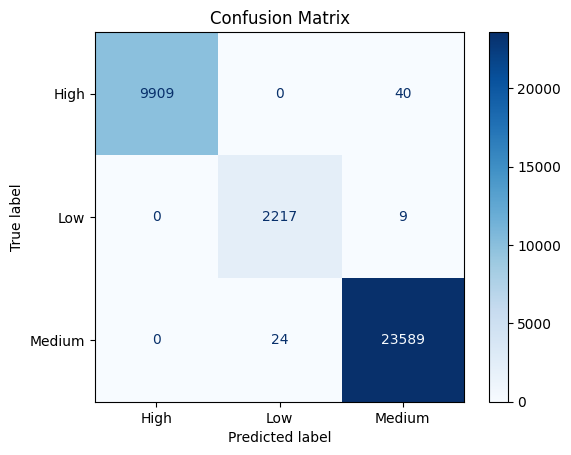

In [ ]:
cm = confusion_matrix(y_test, svm_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=svm.classes_
)

plt.figure(figsize=(7,7))

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

In [ ]:
def predict_priority(query):

    vec = vectorizer.transform([query])

    prediction = svm.predict(vec)

    return prediction[0]

In [ ]:
predict_priority("My tomato crop has suddenly dried after heavy rain.")

'High'

In [ ]:
predict_priority("What is today's market price of wheat?")

'Low'

In [ ]:
import joblib

joblib.dump(svm, "priority_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


In [ ]:
def predict_farmer_query(query):

    vec = vectorizer.transform([query])

    priority = svm.predict(vec)[0]

    print("="*50)
    print("Farmer Query")
    print(query)
    print("="*50)
    print("Predicted Priority :", priority)

    if priority == "High":
        print("Suggested Action : Immediate expert attention recommended.")

    elif priority == "Medium":
        print("Suggested Action : Advisory response recommended.")

    else:
        print("Suggested Action : General information can be provided.")

In [ ]:
predict_farmer_query("My cotton crop has suddenly turned yellow and insects are attacking.")

Farmer Query
My cotton crop has suddenly turned yellow and insects are attacking.
Predicted Priority : High
Suggested Action : Immediate expert attention recommended.


In [ ]:
predict_farmer_query("What is the market price of wheat today?")

Farmer Query
What is the market price of wheat today?
Predicted Priority : Low
Suggested Action : General information can be provided.


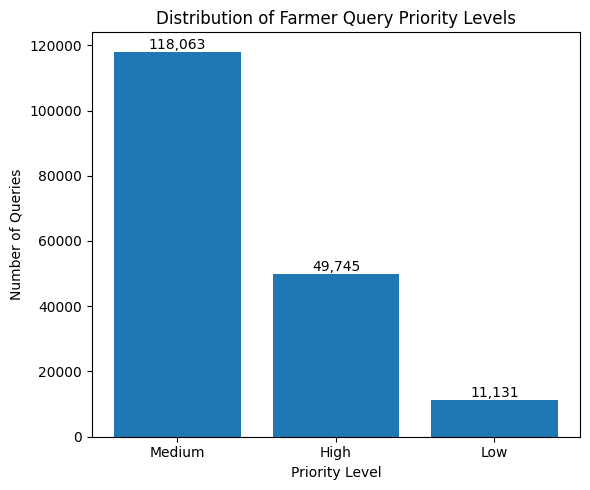

In [ ]:
import matplotlib.pyplot as plt

priority_counts = df["Priority"].value_counts()

plt.figure(figsize=(6,5))

bars = plt.bar(priority_counts.index, priority_counts.values)

plt.title("Distribution of Farmer Query Priority Levels")
plt.xlabel("Priority Level")
plt.ylabel("Number of Queries")

# Add value labels above each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:,}',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()
plt.show()

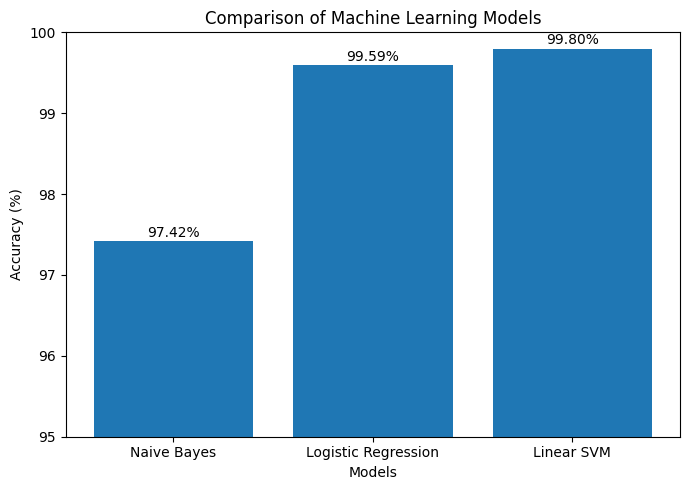

In [ ]:
import matplotlib.pyplot as plt

models = ["Naive Bayes", "Logistic Regression", "Linear SVM"]
accuracy = [97.42, 99.59, 99.80]

plt.figure(figsize=(7,5))
bars = plt.bar(models, accuracy)

plt.title("Comparison of Machine Learning Models")
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")
plt.ylim(95, 100)

# Add value labels
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.05,
        f"{bar.get_height():.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()